In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os dados limpos pelo Felipe
df = pd.read_csv('../dados/processed/netflix_clean.csv')

# Filtrar apenas filmes, já que sua parte é sobre eles
df_movies = df[df['type'] == 'Movie'].copy()

In [8]:
# Lendo o arquivo que o Felipe limpou
# O '../' sobe uma pasta para encontrar o arquivo csv
df = pd.read_csv('../dados/processed/netflix_clean.csv')

# Vamos filtrar apenas os filmes, já que séries é a parte do Andrey
df_filmes = df[df['type'] == 'Movie'].copy()

# Mostrar as primeiras 5 linhas para ver se deu certo
df_filmes.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,years_to_netflix,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Não Informado,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,1.0,90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Não Informado,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0,0.0,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0,28.0,125
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0,0.0,104
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0,0.0,127


In [10]:
# 1. Primeiro, vamos remover qualquer linha onde a duração esteja vazia
df_filmes = df_filmes.dropna(subset=['duration'])

# 2. Agora, vamos limpar o texto e converter
# Usamos 'errors=coerce' por segurança e preenchemos com 0 se algo falhar
df_filmes['duration_num'] = pd.to_numeric(df_filmes['duration'].str.replace(' min', ''), errors='coerce')

# 3. Removemos se sobrou algum erro na conversão
df_filmes = df_filmes.dropna(subset=['duration_num'])

# 4. Transformamos em número inteiro
df_filmes['duration_num'] = df_filmes['duration_num'].astype(int)

print("Agora sim! Duração convertida e valores vazios removidos.")
print(f"Total de filmes para análise: {len(df_filmes)}")

Agora sim! Duração convertida e valores vazios removidos.
Total de filmes para análise: 6128


In [11]:
media = df_filmes['duration_num'].mean()
mediana = df_filmes['duration_num'].median()

print(f"Média: {media:.2f} min")
print(f"Mediana: {mediana:.2f} min")

Média: 99.58 min
Mediana: 98.00 min


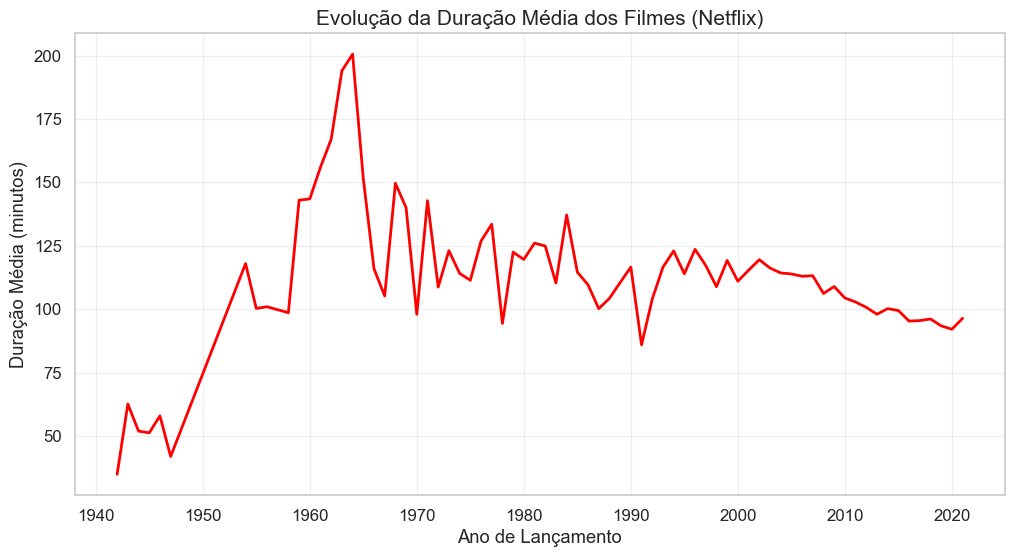

In [22]:
# Criar o gráfico
plt.figure(figsize=(12, 6))
sns.lineplot(data=tendencia, x='release_year', y='duration_num', color='red', linewidth=2)
plt.title('Evolução da Duração Média dos Filmes (Netflix)', fontsize=15)
plt.xlabel('Ano de Lançamento')
plt.ylabel('Duração Média (minutos)')
plt.grid(alpha=0.3)
plt.show()

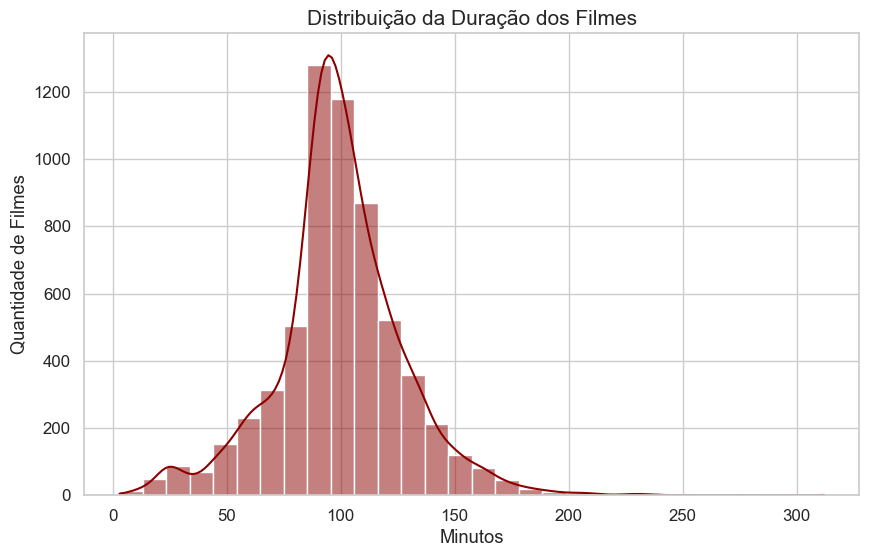

In [19]:
plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(df_filmes['duration_num'], bins=30, kde=True, color='darkred')
plt.title('Distribuição da Duração dos Filmes', fontsize=15)
plt.xlabel('Minutos')
plt.ylabel('Quantidade de Filmes')
plt.show()

In [15]:
print(f"Filme mais longo: {df_filmes['duration_num'].max()} min")
print(f"Filme mais curto: {df_filmes['duration_num'].min()} min")

Filme mais longo: 312 min
Filme mais curto: 3 min
